# 1. Análisis Exploratorio

In [ ]:
import re
import random
from sklearn.feature_extraction.text import TfidfVectorizer
import unicodedata
from nltk import ngrams, FreqDist
from tools import read_json
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.model_selection import train_test_split
import spacy
import numpy as np
from sklearn.manifold import TSNE
from wordcloud import WordCloud
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score
)
import multiprocessing
from gensim.models import Word2Vec
import warnings
warnings.filterwarnings('ignore')

pretrained_model = "en_core_web_md"
path = "Amazon_Instant_Video_5.json"

In [ ]:
# !python -m spacy download en_core_web_md

Se define el uso del modelo base como: **"en_core_web_md"**

In [ ]:
nlp = spacy.load(pretrained_model)

Se Lee el archivo JSON y crea un dataframe para mejor manejo de data a fines de análisis exploratorio. Pandas resulta más conveniente que python en operaciones iterativas dado que está optimizado para aplicación de funciones sobre datos..

In [ ]:
data = read_json(path)
df = pd.DataFrame(data)

## 1.1 Exploración de Estructura de Datos

In [ ]:
# Mostramos información básica sobre el dataframe
print(f"Total reseñas: {df.shape[0]}")
print(df.head())
print(df.info())
print(f"Total records: {len(data)}")

Se redefine el dataframe para solo tener las columnas que nos interesan. El resto no serán usados para el análisis exploratorio.

In [142]:
# Se eliminan las columnas que no se usarán para el análisis exploratorio.
df = df[["reviewText", "overall"]]
df.head()

,reviewText,overall
0,I had big expectations because I love English ...,2.0
1,I highly recommend this series. It is a must f...,5.0
2,This one is a real snoozer. Don't believe anyt...,1.0
3,Mysteries are interesting. The tension betwee...,4.0
4,"This show always is excellent, as far as briti...",5.0


Se realiza la partición de la data en train, validation y test que eventualmente usaremos para entrenar y evaluar el modelo eventualmente.

In [143]:
# Split data
train_data, test_data = train_test_split(df, test_size=0.3, random_state=44, stratify=df["overall"])
train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

Se revisa el dataset para ver si tiene valores nulos y se puede apreciar que para el train existen datos nulos en reviewName

In [144]:
# Estadísticas de Train Dataset
train_df.info()

<class 'pandas.DataFrame'>
Index: 25988 entries, 25635 to 10848
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   reviewText  25988 non-null  str    
 1   overall     25988 non-null  float64
dtypes: float64(1), str(1)
memory usage: 609.1 KB


Se hacen gráficas para poder observar la distribución de overall (o estrellas) presentes en el train dataset. Observándose que la mayoría de las reseñas son buenas (4 y 5 estrellas).

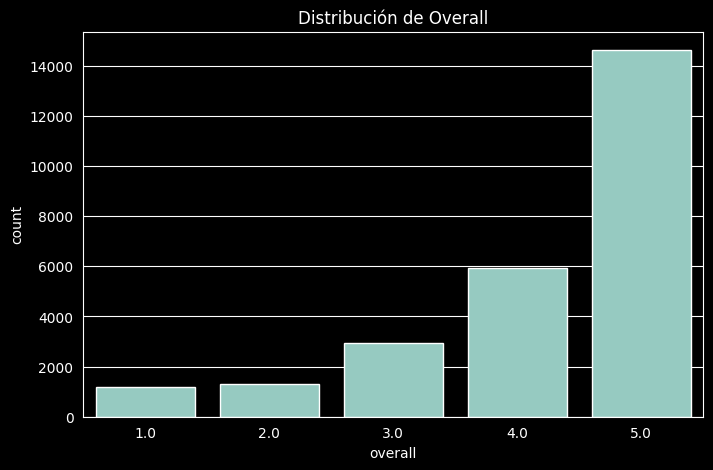

In [145]:
# Distribución de estrellas
plt.figure(figsize=(8, 5))
sns.countplot(x='overall', data=train_df)
plt.title('Distribución de Overall')
plt.show()

In [146]:
# Porcentaje de reseñas por estrella
print(
    f"Menores o iguales a 3 stars: {train_df["overall"][train_df["overall"] <= 3].count()} => {train_df["overall"][train_df["overall"] <= 3].count() / train_df.shape[0] * 100:.2f}%")
print(
    f"Mayores a 3 stars: {train_df["overall"][train_df["overall"] > 3].count()} => {train_df["overall"][train_df["overall"] > 3].count() / train_df.shape[0] * 100:.2f}%")

Menores o iguales a 3 stars: 5453 => 20.98%
Mayores a 3 stars: 20535 => 79.02%


Al graficar las longitudes de las de las reviews (o reseñas), se observan que la mayoría es contienen menos de 100 palabras.

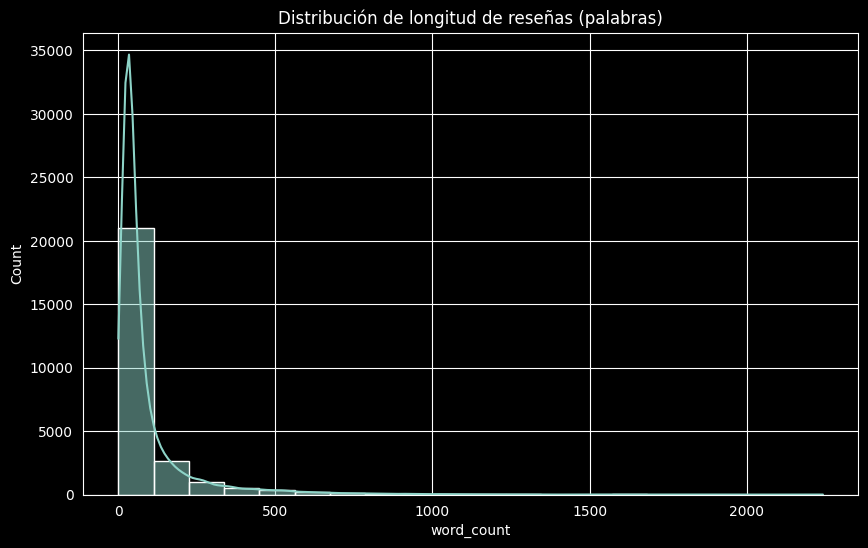

In [147]:
# Calcular longitud en palabras
train_df['word_count'] = train_df['reviewText'].apply(lambda x: len(str(x).split()))
# Histograma de longitud
plt.figure(figsize=(10, 6))
sns.histplot(train_df['word_count'], bins=20, kde=True)
plt.title('Distribución de longitud de reseñas (palabras)')
plt.show()

Al formularse las estadísticas descriptivas, se puede apreciar que la mayoría de las reseñas contienen menos de 100 palabras. La media es de 90 palabras aproximadamente y el percentil del 75% tiene menos de 87 palabras.

In [148]:
# Ver estadísticas (media, max, min)
print(train_df['word_count'].describe())

count    25988.000000
mean        90.649338
std        139.767123
min          1.000000
25%         26.000000
50%         42.000000
75%         87.000000
max       2242.000000
Name: word_count, dtype: float64


A continuación se realiza un análisis rápido preparatorio para Word2Vec. En este caso sí se puede usar el dataset completo porque no se usan las etiquetas en ningún caso y la idea no es desarrollar, de momento, un modelo predictivo. Solo pretende encontrar los términos y palabras más comunes y su frecuencia en las reseñas.

In [149]:
# Análisis rápido preparatorio para Word2Vec
sample_reviews = train_df['reviewText'].head(10000).tolist()

tokens = []
lemmas = []
adjetivos = []

# Procesamos con nlp.pipe
for doc in nlp.pipe(sample_reviews, disable=["ner", "parser"]):
    # Filtramos stop words y puntuación
    tokens.extend([token.text.strip().lower() for token in doc if
                   not token.is_stop and not token.is_punct and len(token.text.strip()) > 0])
    lemmas.extend([token.lemma_.strip().lower() for token in doc if
                   not token.is_stop and not token.is_punct and len(token.text.strip()) > 0])
    # Extraemos adjetivos (muy útil para análisis de sentimientos)
    adjetivos.extend(
        [token.text.strip().lower() for token in doc if token.pos_ == "ADJ" and len(token.text.strip()) > 0])

In [150]:
# Análisis de palabras comunes o frecuentes
n = 10
# Palabras más comunes
word_freq = Counter(tokens)
word_freq_df = pd.DataFrame(columns=["word", "count"])

for word in word_freq.most_common(n):
    new_record = pd.DataFrame(data={"word": [word[0]], "count": [word[1]]})
    word_freq_df = pd.concat([word_freq_df, new_record])

# Adjetivos más comunes
adj_freq = Counter(adjetivos)
adj_freq_df = pd.DataFrame(columns=["word", "count"])

for word in adj_freq.most_common(n):
    new_record = pd.DataFrame(data={"word": [word[0]], "count": [word[1]]})
    adj_freq_df = pd.concat([adj_freq_df, new_record])

print(f"Top {n} de palabras:")
print(word_freq_df.reset_index(drop="index"))

print(f"Top {n} de adjetivos:")
print(adj_freq_df.reset_index(drop="index"))

Top 10 de palabras:
         word count
0      season  4521
1        like  3874
2        good  3426
3      series  3417
4       great  2885
5        love  2418
6       watch  2402
7  characters  2362
8       story  2188
9       movie  2026
Top 10 de adjetivos:
          word count
0         good  3320
1        great  2829
2         more  2039
3        other  1392
4        first  1359
5  interesting  1211
6          new  1174
7         many  1034
8       little  1021
9         best   933


Con fines de representación más ilustrativa, se grafica un wordcloud con las palabras más comunes.

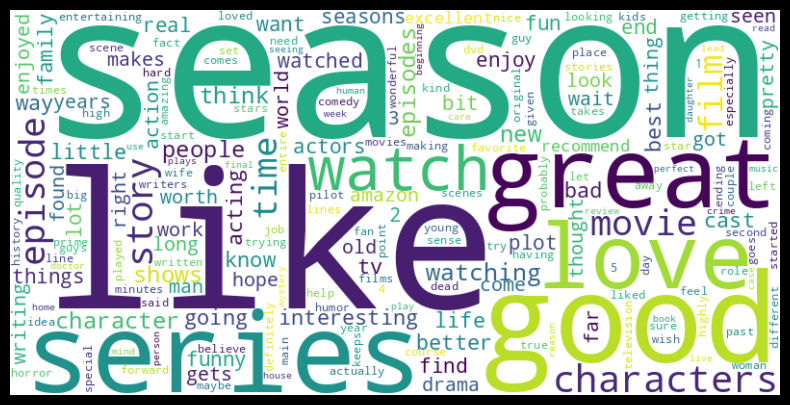

In [151]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

### N-grams
Los n-grams son fundamentales porque capturan patrones y contexto local del texto. Permiten identificar qué palabras tienden a aparecer juntas.

In [152]:
unigrams_ = ngrams(tokens, 1)
bigrams_ = ngrams(tokens, 2)
trigrams_ = ngrams(tokens, 3)

unigrams_freq_ = FreqDist(unigrams_)
bigrams_freq_ = FreqDist(bigrams_)
trigrams_freq_ = FreqDist(trigrams_)

Seguidamente, se muestran los n-grams más comunes, tomando en cuenta las 5 primeras posiciones como ejemplo.

In [153]:
unigrams_freq_.most_common(5)

[(('season',), 4521),
 (('like',), 3874),
 (('good',), 3426),
 (('series',), 3417),
 (('great',), 2885)]

In [154]:
bigrams_freq_.most_common(5)

[(('season', '2'), 331),
 (('story', 'line'), 325),
 (('season', '1'), 276),
 (('season', '3'), 242),
 (('sci', 'fi'), 204)]

In [155]:
trigrams_freq_.most_common(5)

[(('looking', 'forward', 'season'), 45),
 (('love', 'love', 'love'), 33),
 (('great', 'story', 'line'), 31),
 (('good', 'story', 'line'), 28),
 (('season', '1', '2'), 26)]

### Función de preprocesamiento para **Embeddings con Word2Vec**

In [156]:
# Función cleaning para preparación de data
def cleaning(doc):
    txt = [token.lemma_.lower() for token in doc if not token.is_stop and not token.is_punct and token.is_alpha]
    return ' '.join(txt)

In [157]:

# Se crea la variable removiendo signos de puntuación demás caracteres que puedan perturbar o no sumar al análisis.
brief_cleaning = (re.sub(r'[^\w\s]', '', str(row)).strip() for row in df['reviewText'])

In [158]:
# Convertir el generador a lista
brief_list = list(brief_cleaning)

# Contar palabras totales
total_words = sum(len(str(text).split()) for text in brief_list)
print(f"Total de palabras: {total_words}")

Total de palabras: 3377240


Se cuentan las palabras totales para tener un valor de referencia y se desea observar la forma de nuestra información en brief_list para chequear la eliminación de signos de puntuación y caracteres especiales.

In [159]:
brief_list[0:5]

['I had big expectations because I love English TV in particular Investigative and detective stuff but this guy is really boring It didnt appeal to me at all',
 'I highly recommend this series It is a must for anyone who is yearning to watch grown up television Complex characters and plots to keep one totally involved Thank you Amazin Prime',
 'This one is a real snoozer Dont believe anything you read or hear its awful I had no idea what the title means Neither will you',
 'Mysteries are interesting  The tension between Robson and the tall blond is good but not always believable  She often seemed uncomfortable',
 'This show always is excellent as far as british crime or mystery showsgoes this is one of the best ever made  The stories are well done and the acting is top notch with interesting twists in the realistic and brutal storylines  This show pulls no punches as it enters into the twisted minds of criminals and the profiler psychiatrist who helps out in a northern english city pol

In [141]:
txt = [cleaning(doc) for doc in nlp.pipe(brief_list[0:10000], batch_size=5000)]

KeyboardInterrupt: 

### Preparación para entrenar modelo (word2vec)

In [160]:
df_clean_reviews = pd.DataFrame({"review_clean": txt})
df_clean_reviews = df_clean_reviews.dropna().drop_duplicates()
print(df_clean_reviews.shape)
print(df_clean_reviews.head())

(9988, 1)
                                        review_clean
0  big expectation love english tv particular inv...
1  highly recommend series yearn watch grow telev...
2  real snoozer not believe read hear awful idea ...
3  mystery interesting tension robson tall blond ...
4  excellent far british crime mystery showsgoe g...


In [161]:
cores = multiprocessing.cpu_count()

w2v_model = Word2Vec(
    min_count=5,
    window=2,
    vector_size=100,
    sample=6e-5,
    alpha=0.03,
    min_alpha=0.0007,
    negative=20,
    workers=cores - 1
)

### Construcción de vocabulario

In [162]:
sent = [row.split() for row in df_clean_reviews["review_clean"]]
w2v_model.build_vocab(sent, progress_per=10000)

In [163]:
print('Vocabulario compuesto por {} palabras'.format(len(w2v_model.wv.key_to_index)))

Vocabulario compuesto por 8334 palabras


### Entrenamiento de modelo Word2Vec

In [164]:
w2v_model.train(sent, total_examples=w2v_model.corpus_count, epochs=20, report_delay=1)

(4546749, 9407660)

In [165]:
keys = ["season", "like", "series", "great"]

In [166]:
w2v_model.wv.most_similar(positive=keys)

[('justified', 0.9705440998077393),
 ('sifi', 0.9570213556289673),
 ('regret', 0.9527388215065002),
 ('flashpoint', 0.9493577480316162),
 ('addictive', 0.9487496614456177),
 ('last', 0.9447283744812012),
 ('continuation', 0.9437932968139648),
 ('watcher', 0.9435074925422668),
 ('here', 0.9430747628211975),
 ('wow', 0.9424735307693481)]

### Creación de cluster de palabras con las keys antes definidas

Se crearán clusters de palabras para visualizar en un gráfico de dispersión y tratar de identificar algún patrón o tendencia de grupos de palabras seleccionadas previamente.

In [167]:
# Se crean los clusters y embeddings de palabras para visualizar en un gráfico de dispersión.
embedding_clusters = []
word_clusters = []
for word in keys:
    embeddings = []
    words = []
    for similar_word, _ in w2v_model.wv.most_similar(word, topn=10):
        words.append(similar_word)
        embeddings.append(w2v_model.wv[similar_word])
    embedding_clusters.append(embeddings)
    word_clusters.append(words)

Se imprimen los clusters de palabras para verificar que se han creado correctamente.

In [168]:
print(word_clusters)

[['second', 'finale', 'episode', 'start', 'renew', 'fifth', 'wait', 'hope', 'beginning', 'fourth'], ['cheesy', 'ok', 'reality', 'awfully', 'superhero', 'kinda', 'watcher', 'imaginative', 'watching', 'staple'], ['justified', 'thoroughly', 'disappoint', 'continue', 'last', 'disappointed', 'regret', 'addictive', 'shame', 'bbc'], ['enjoyable', 'wellwritten', 'wellacte', 'shine', 'good', 'fantastic', 'absolutely', 'entertaining', 'engaging', 'justified']]


Se imprimen los embeddings de palabras para verificar que se han creado correctamente.

In [169]:
embedding_clusters[0]

[array([-4.83732253e-01,  1.36259288e-01, -8.10217112e-02,  5.84570020e-02,
         4.81027275e-01, -4.14165944e-01,  9.63486545e-03,  8.45236480e-01,
        -3.78559947e-01, -3.53196055e-01, -3.83784734e-02, -5.19548655e-01,
         2.84075081e-01,  1.89767092e-01,  1.72707736e-01,  1.46572366e-02,
         1.59329310e-01, -3.47890347e-01,  3.45340133e-01, -7.32007861e-01,
         1.29132196e-01,  1.95889577e-01, -1.69477999e-01, -2.52099127e-01,
        -2.06386801e-02,  2.54916400e-01, -2.52880901e-01,  1.01921931e-01,
        -2.25514844e-01, -2.18242332e-02,  2.35751137e-01,  1.06218815e-01,
         1.76853314e-01,  7.03080967e-02, -3.02256700e-02,  5.32052875e-01,
         5.67073286e-01, -1.44185796e-01, -5.16896367e-01, -3.48755896e-01,
         7.10008591e-02, -2.64997929e-01,  3.51231754e-01, -1.08575739e-01,
         3.26838493e-01,  3.34941804e-01, -4.93021220e-01, -2.67322659e-01,
         1.95267588e-01,  1.79395244e-01,  7.94869781e-01, -2.56750524e-01,
        -6.7

### Reducción de dimensionalidad a 2D

In [170]:
# Se define el t-Distributed Stochastic Neighbor Embedding (t-SNE) para reducir la dimensionalidad de los embeddings a 2D.
tsne_model_2d = TSNE(perplexity=27, n_components=2, init='pca', max_iter=3500, random_state=32)

In [171]:
# Se convierten los embeddings a un array numpy para su mejor manejo.
embedding_clusters = np.array(embedding_clusters)
n, m, k = embedding_clusters.shape
embedding_clusters.shape

(4, 10, 100)

In [172]:
# Se aplica el t-SNE para reducir la dimensionalidad de los embeddings a 2D.
v_2d = tsne_model_2d.fit_transform(embedding_clusters.reshape(n * m, k))
v_2d.shape

(40, 2)

In [173]:
# # Se redimensionan los embeddings para su mejor manejo.
embeddings_2d = v_2d.reshape(n, m, 2)
embeddings_2d.shape

(4, 10, 2)

### Gráfica de clusters

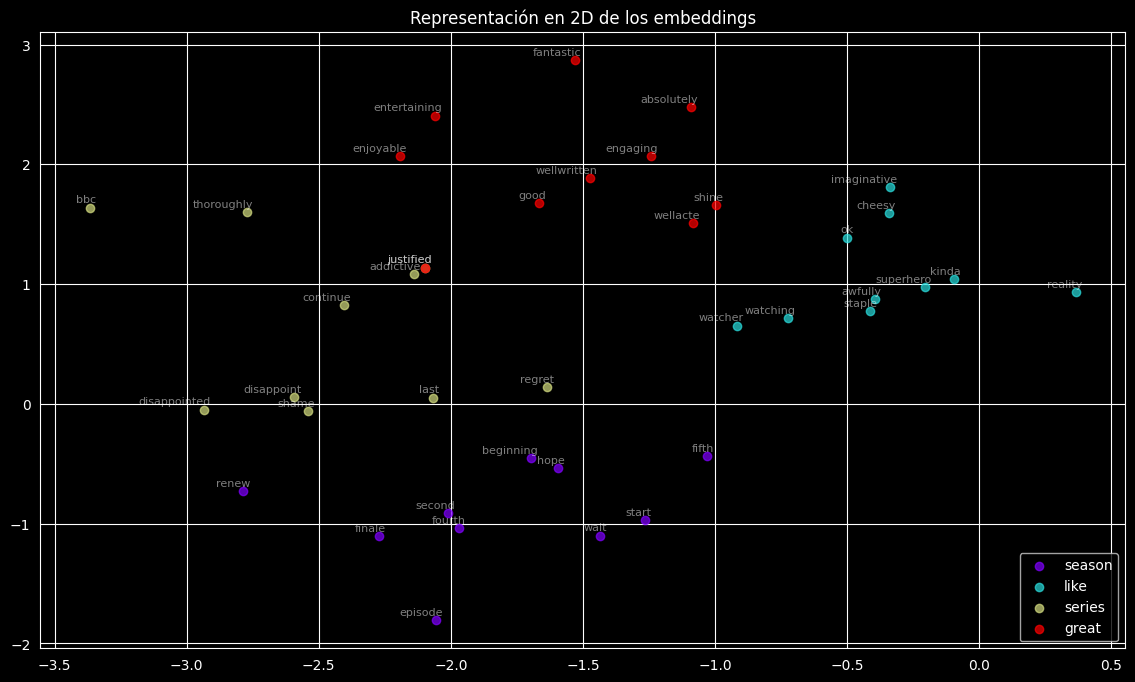

In [174]:
# Función para graficar los clusters de palabras.
def tsne_plot_similar_words(labels, embedding_clusters, word_clusters, a=0.7):
    plt.figure(figsize=(14, 8))
    colors = cm.rainbow(np.linspace(0, 1, len(labels)))
    for label, embeddings, words, color in zip(labels, embedding_clusters, word_clusters, colors):
        x = embeddings[:,0]
        y = embeddings[:,1]
        plt.scatter(x, y, c=[color], alpha=a, label=label)
        for i, word in enumerate(words):
            plt.annotate(word, alpha=0.5, xy=(x[i], y[i]), xytext=(5, 2),
                         textcoords='offset points', ha='right', va='bottom', size=8)
    plt.legend(loc=4)
    plt.grid(True)
    plt.title('Representación en 2D de los embeddings')
    plt.show()

tsne_plot_similar_words(keys, embeddings_2d, word_clusters)

## Observaciones del análisis exploratorio


- El dataset contiene 37.126 reseñas de Amazon Instant Video, se ha dividido en conjuntos de train (70%), validación y test (15% cada uno).
- El corpus está muy desbalanceado. La mayor parte del overall (futuro target para el estudio) es mayor a 3 estrellas.
- Las reseñas son mayoritariamente cortas (menos de 100 palabras).
- Las palabras más frecuentes (season, series, great, love) y adjetivos (good, great, interesting) reflejan un tono general positivo.
- Se entrenó un modelo Word2Vec obteniendo embeddings semánticamente coherentes con el dominio.
- Los clusters de palabras generados muestran agrupaciones temáticas claras: continuidad narrativa, calidad percibida y tipo de contenido, validando la calidad de los embeddings.
- El pipeline de preprocesamiento (limpieza, lematización con spaCy, eliminación de stopwords) es adecuado como base para un futuro clasificador de sentimientos.

# 2. Preprocesado de texto

In [175]:
# Definición de stop words en una variable
sw_list = nlp.Defaults.stop_words

In [176]:
# De finición de función de preprocesamiento de los reviews
def process_reviews(reviews, sw_list=None):
    processed_sentences = []

    for sent in reviews:
        if sent != sent:
            processed_sentences.append('None')
            continue

        # Normalización y minúsculas
        sent = unicodedata.normalize('NFKD', sent).encode('ascii', errors='ignore').decode('utf-8').lower()
        # Separar palabras unidas por caracteres especiales (como: "hello,world" -> "hello world")
        sent = re.sub(r'[^a-z\s]', ' ', sent)
        # Eliminar espacios múltiples
        sent = re.sub(r' +', ' ', sent).strip()

        # Stopwords (opcional)
        if sw_list:
            sent = ' '.join([word for word in sent.split() if word not in sw_list or word == 'no'])

        processed_sentences.append(sent)

    return processed_sentences

Ahora, se usa la antes definida para crear listas con los reviews procesados. que posteriormente se usarán para crear un campo o columna en cada dataframe denominado "reviewProcessed".

In [177]:
# Se crean las listas de reviews procesados para train y test.
train_processed_reviews = process_reviews(train_df['reviewText'], sw_list)
test_processed_reviews = process_reviews(test_df['reviewText'], sw_list)

train_df["reviewProcessed"] = train_processed_reviews
test_df["reviewProcessed"] = test_processed_reviews

In [178]:
train_df.head()

,reviewText,overall,word_count,reviewProcessed
25635,I have rated this before I think this is sharp...,5.0,20,rated think sharp fast moving funny times word...
28155,I rally like thia mini series. It follows the...,5.0,22,rally like thia mini series follows book prett...
10617,It was just ok.,3.0,4,ok
32215,The first season of this show was great!And th...,3.0,22,season great second season started good appear...
36476,I love the hope this movie gives people. There...,5.0,29,love hope movie gives people little things har...


Luego se convierte la colección de documentos de texto y se transforma en una matriz numérica donde cada valor representa la importancia de una palabra en un documento relativa a toda la colección.

In [179]:
cv = TfidfVectorizer(
    max_df=0.95,
    min_df=3,
    max_features=2500,
    strip_accents='ascii',
    ngram_range=(1, 3)
)
cv.fit(train_df['reviewProcessed'])

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",'ascii'
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.",

In [180]:
print(list(cv.vocabulary_.items())[:50])

print(f"La extensión del vocabulario es de {len(cv.vocabulary_)} palabras.")


[('rated', 1767), ('think', 2229), ('sharp', 1967), ('fast', 777), ('moving', 1485), ('funny', 892), ('times', 2247), ('words', 2461), ('like', 1296), ('mini', 1448), ('series', 1946), ('follows', 852), ('book', 220), ('pretty', 1697), ('read', 1774), ('books', 221), ('wait', 2366), ('second', 1923), ('season', 1908), ('mini series', 1449), ('second season', 1924), ('ok', 1559), ('great', 962), ('started', 2084), ('good', 934), ('appears', 107), ('running', 1868), ('season great', 1915), ('love', 1357), ('hope', 1073), ('movie', 1482), ('gives', 922), ('people', 1613), ('little', 1317), ('things', 2228), ('hard', 1013), ('good movie', 941), ('lovers', 1370), ('film', 817), ('viewer', 2353), ('care', 282), ('characters', 323), ('dark', 491), ('moments', 1465), ('light', 1294), ('depressing', 529), ('story', 2108), ('style', 2133), ('tale', 2180), ('choices', 345)]
La extensión del vocabulario es de 2500 palabras.


Se ajustan los datos X (input) y y (output) para entrenar el modelo.

In [181]:
X_train_ = cv.transform(train_df['reviewProcessed'])
y_train_ = train_df['overall']
X_test_ = cv.transform(test_df['reviewProcessed'])
y_test_ = test_df['overall']

Creamos una lista de palabras presentes y no presentes en nuestro vocabulario.

In [182]:
# Toma de palabras de ejemplo
words_example = [
    "good",
    "awesome",
    "bad",
    "series",
    "movies",
    "video",
    "tennis"
]

In [183]:
vocab_idf = dict(zip(cv.get_feature_names_out(), cv.idf_))

print('{0:20}{1:20}'.format('Palabra', 'IDF'))
for word in words_example:
    if word not in vocab_idf:
        print('{0:20}{1:20}'.format(word, 'OOV'))
    else:
        print('{0:20}{1:2.3f}'.format(word, vocab_idf[word]))

Palabra             IDF                 
good                2.388
awesome             4.770
bad                 3.600
series              2.506
movies              4.320
video               4.856
tennis              OOV                 


In [184]:
# Se toma una muestra aleatoria de las review procesado y su overall
i = random.randint(0, X_train_.shape[0])
print(f"Review: {train_df['reviewProcessed'].iloc[i]}")
print(f"Overall: {train_df['overall'].iloc[i]}")


Review: wish started watching beginning marathoning dreading episodes runout
Overall: 4.0


In [185]:
# Se obtiene el vector TF-IDF de la review procesada
doc_vector = X_train_[i]
df_tfidf = pd.DataFrame(doc_vector.T.todense(), index=cv.get_feature_names_out(), columns=['tfidf'])
df_tfidf = df_tfidf[df_tfidf['tfidf'] > 0]

top_n = 10
print(f'Top {top_n} words with highest TF_IDF in the review {i}:\n{df_tfidf.sort_values(by=["tfidf"],ascending=False)[:top_n]}')
print(f'\nTop {top_n} words with lowest TF_IDF in the review {i}:\n{df_tfidf.sort_values(by=["tfidf"],ascending=False)[-top_n:]}')

Top 10 words with highest TF_IDF in the review 15761:
                     tfidf
started watching  0.539884
beginning         0.438951
started           0.417017
wish              0.413777
episodes          0.304656
watching          0.279137

Top 10 words with lowest TF_IDF in the review 15761:
                     tfidf
started watching  0.539884
beginning         0.438951
started           0.417017
wish              0.413777
episodes          0.304656
watching          0.279137


---
# 3. Modelo Predictivo — Clasificación de Sentimiento

Se entrena y evalúa un conjunto de modelos de clasificación para predecir el sentimiento de las reseñas (binario: positivo/negativo) a partir de los vectores TF-IDF.

## Preparación de Targets

Se define la variable objetivo como **binaria**: overall > 3 → positivo, overall ≤ 3 → negativo. Esto es consistente con el análisis exploratorio previo.

In [186]:
train_df['sentimiento'] = train_df['overall'].apply(lambda x: 'positivo' if x > 3 else 'negativo')
test_df['sentimiento']  = test_df['overall'].apply(lambda x: 'positivo' if x > 3 else 'negativo')

y_train_sent = train_df['sentimiento']
y_test_sent  = test_df['sentimiento']

print('Distribución de clases — Train:')
print(train_df['sentimiento'].value_counts())
print(f"  Ratio positivo/negativo: {train_df['sentimiento'].value_counts()['positivo'] / train_df['sentimiento'].value_counts()['negativo']:.2f}")
print()
print('Distribución de clases — Test:')
print(test_df['sentimiento'].value_counts())

Distribución de clases — Train:
sentimiento
positivo    20535
negativo     5453
Name: count, dtype: int64
  Ratio positivo/negativo: 3.77

Distribución de clases — Test:
sentimiento
positivo    8801
negativo    2337
Name: count, dtype: int64


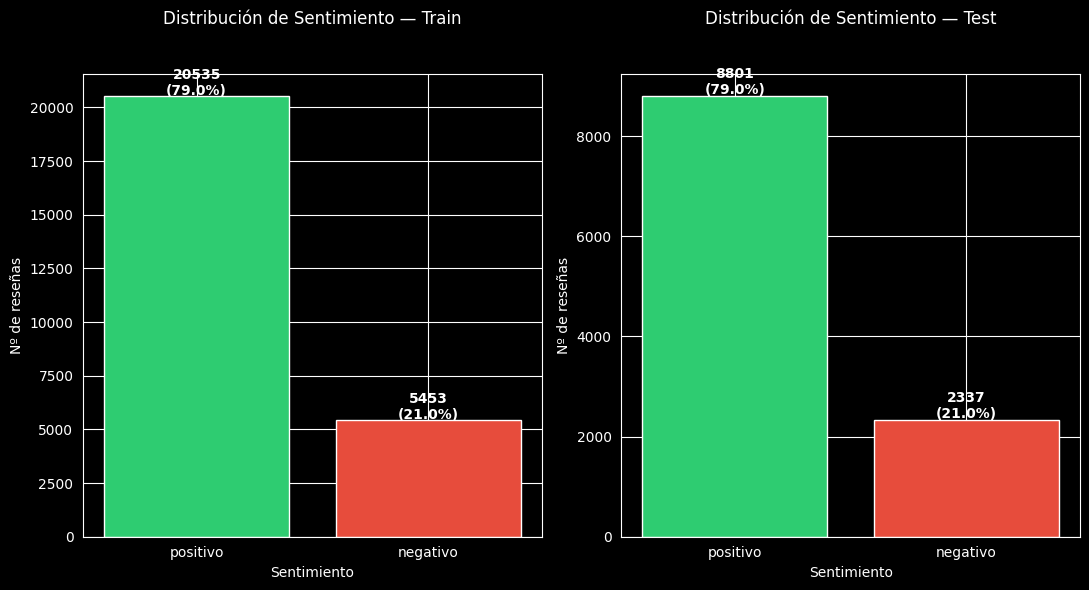

In [187]:
# Visualización de distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(11, 6))
for ax, df_, title in zip(axes, [train_df, test_df], ['Train', 'Test']):
    counts = df_['sentimiento'].value_counts()
    ax.bar(counts.index, counts.values, color=['#2ecc71', '#e74c3c'])
    ax.set_title(f'Distribución de Sentimiento — {title}\n\n')
    ax.set_xlabel('Sentimiento')
    ax.set_ylabel('Nº de reseñas')
    total = counts.sum()
    for i, (label, v) in enumerate(counts.items()):
        ax.text(i, v + 30, f'{v}\n({v/total*100:.1f}%)', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Entrenamiento de Modelos

Se usan los vectores TF-IDF ya calculados (`X_train_`, `X_test_`). Se entrenan tres clasificadores: **Logistic Regression**, **SVM (LinearSVC)** y **Random Forest**.

In [188]:
# Se definen los modedlos a usar
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=44),
    'SVM (LinearSVC)':     LinearSVC(max_iter=2000, random_state=44),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=44, n_jobs=-1),
}

results = {}

for name, model in models.items():
    print('=' * 60)
    print(f'  Modelo: {name}')
    print('=' * 60)
    model.fit(X_train_, y_train_sent)
    y_pred = model.predict(X_test_)
    acc = accuracy_score(y_test_sent, y_pred)
    results[name] = {'model': model, 'y_pred': y_pred, 'accuracy': acc}
    print(f'Accuracy: {acc:.4f}')
    print(classification_report(y_test_sent, y_pred))
    print()

  Modelo: Logistic Regression
Accuracy: 0.8579
              precision    recall  f1-score   support

    negativo       0.77      0.46      0.58      2337
    positivo       0.87      0.96      0.91      8801

    accuracy                           0.86     11138
   macro avg       0.82      0.71      0.75     11138
weighted avg       0.85      0.86      0.84     11138


  Modelo: SVM (LinearSVC)
Accuracy: 0.8580
              precision    recall  f1-score   support

    negativo       0.71      0.54      0.62      2337
    positivo       0.89      0.94      0.91      8801

    accuracy                           0.86     11138
   macro avg       0.80      0.74      0.76     11138
weighted avg       0.85      0.86      0.85     11138


  Modelo: Random Forest
Accuracy: 0.8295
              precision    recall  f1-score   support

    negativo       0.78      0.26      0.39      2337
    positivo       0.83      0.98      0.90      8801

    accuracy                           0.83     1

## Matrices de Confusión

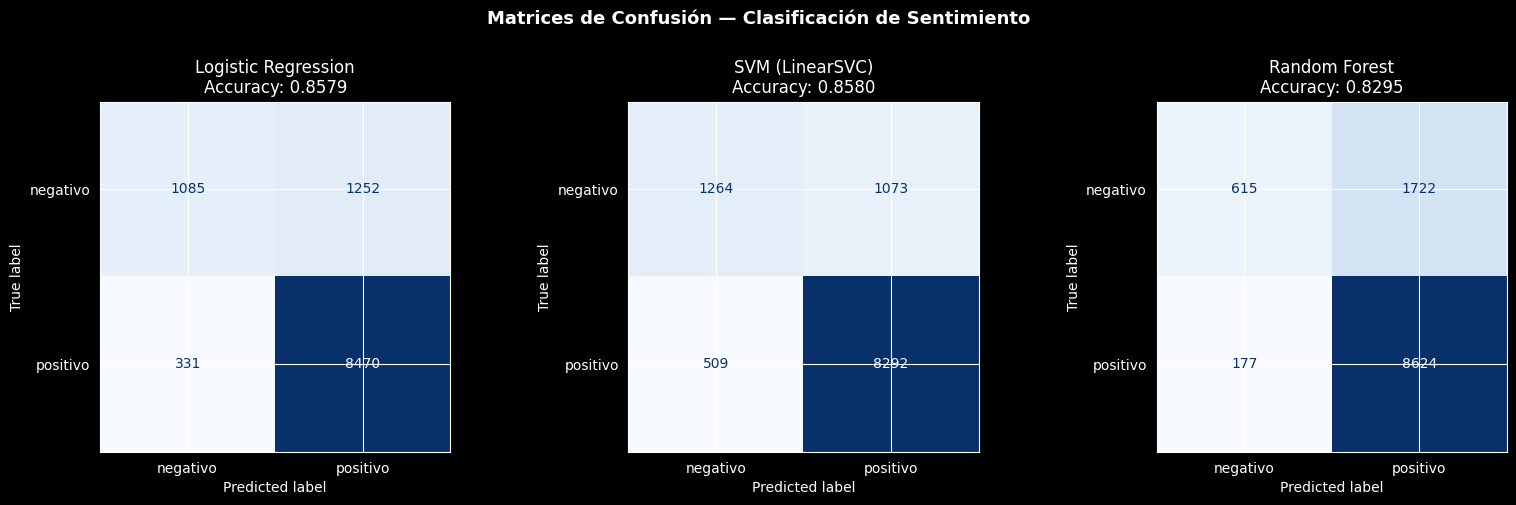

In [189]:
# Se presentan matrices de confusión para examinar más detalladamente el desempeño de los modelos
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
class_order = ['negativo', 'positivo']

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test_sent, res['y_pred'], labels=class_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nAccuracy: {res['accuracy']:.4f}")

plt.suptitle('Matrices de Confusión — Clasificación de Sentimiento\n', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Comparativa de Modelos

             Modelo  Accuracy
    SVM (LinearSVC)  0.857964
Logistic Regression  0.857874
      Random Forest  0.829503


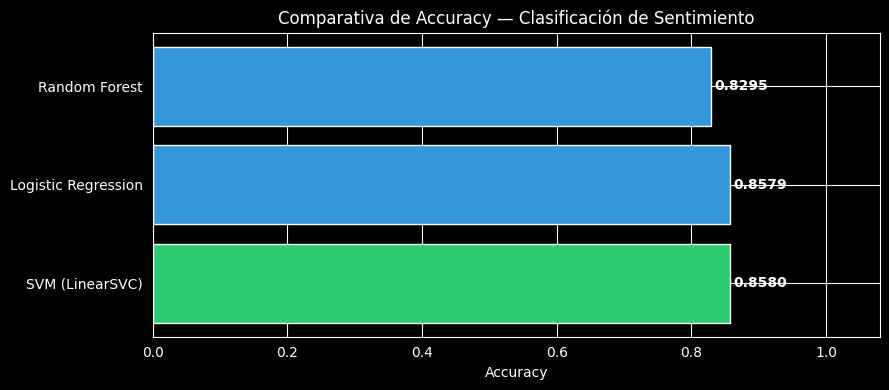

In [190]:
# Luego se desarrolla el comparativo de los modelos presentándose de forma gráfica
comparison_df = pd.DataFrame({
    'Modelo':   list(results.keys()),
    'Accuracy': [res['accuracy'] for res in results.values()]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print(comparison_df.to_string(index=False))

colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(comparison_df))]
plt.figure(figsize=(9, 4))
bars = plt.barh(comparison_df['Modelo'], comparison_df['Accuracy'], color=colors)
plt.xlabel('Accuracy')
plt.title('Comparativa de Accuracy — Clasificación de Sentimiento')
plt.xlim(0, 1.08)
for bar, val in zip(bars, comparison_df['Accuracy']):
    plt.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Palabras Más Influyentes por Clase

Se inspeccionan los coeficientes de los modelos lineales (LR y SVM) para identificar qué palabras son más predictivas de sentimiento positivo y negativo.

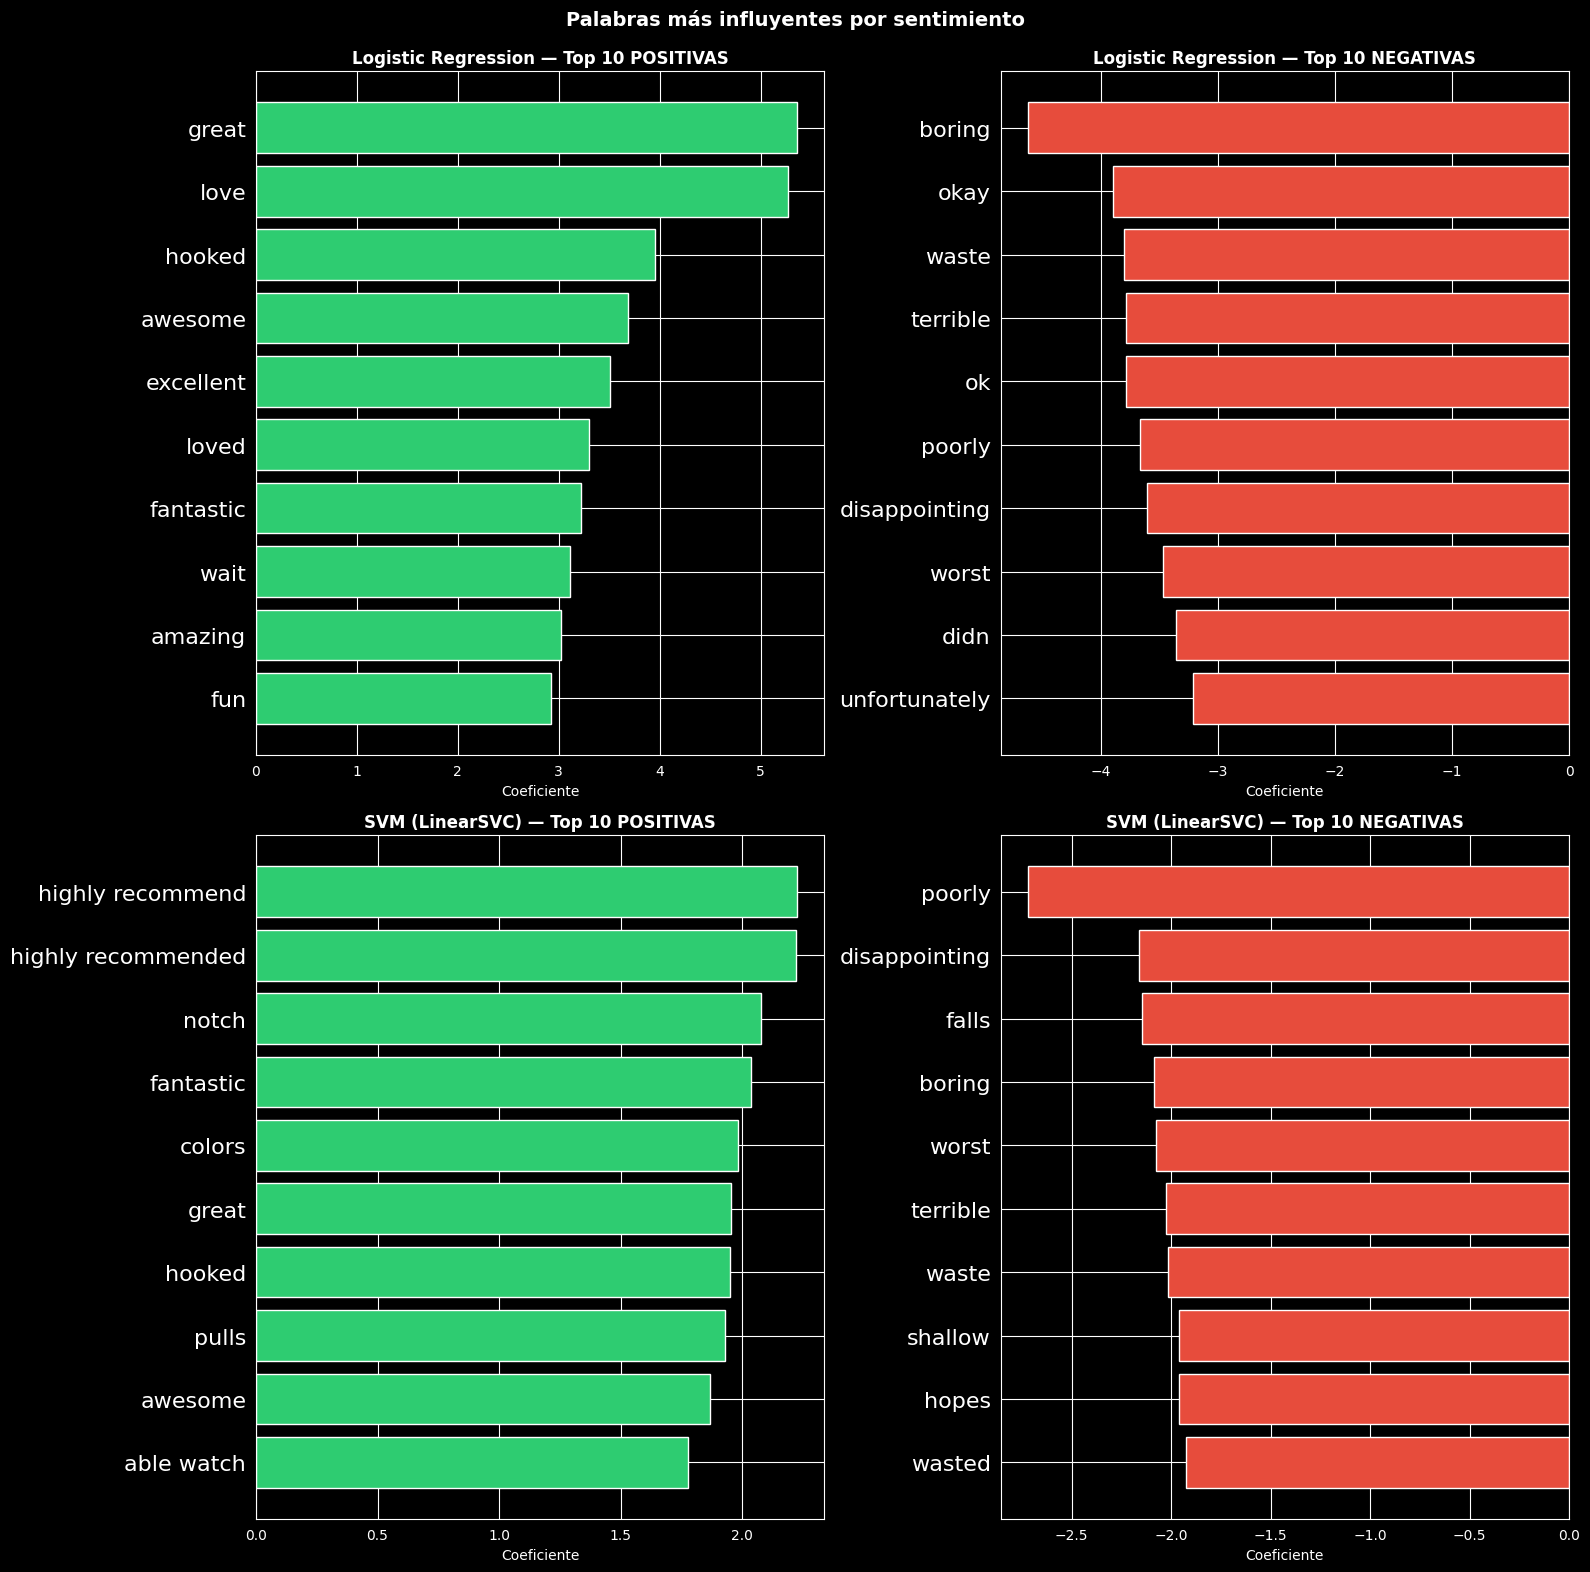

In [191]:
fig, axes = plt.subplots(2, 2, figsize=(16, 16))
feature_names = cv.get_feature_names_out()
top_n = 10
linear_models = {k: v for k, v in results.items() if k in ['Logistic Regression', 'SVM (LinearSVC)']}

for row_idx, (name, res) in enumerate(linear_models.items()):
    coefs = res['model'].coef_[0]

    # Top palabras positivas
    top_pos_idx = np.argsort(coefs)[-top_n:][::-1]
    axes[row_idx][0].barh(
        [feature_names[i] for i in top_pos_idx][::-1],
        coefs[top_pos_idx][::-1], color='#2ecc71')
    axes[row_idx][0].tick_params(axis='y', labelsize=16)
    axes[row_idx][0].set_title(f'{name} — Top {top_n} POSITIVAS', fontweight='bold')
    axes[row_idx][0].set_xlabel('Coeficiente')

    # Top palabras negativas
    top_neg_idx = np.argsort(coefs)[:top_n]
    axes[row_idx][1].barh(
        [feature_names[i] for i in top_neg_idx][::-1],
        coefs[top_neg_idx][::-1], color='#e74c3c')
    axes[row_idx][1].tick_params(axis='y', labelsize=16)
    axes[row_idx][1].set_title(f'{name} — Top {top_n} NEGATIVAS', fontweight='bold')
    axes[row_idx][1].set_xlabel('Coeficiente')

plt.suptitle('Palabras más influyentes por sentimiento\n', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Ejemplos de Predicción

Muestra de predicciones correctas e incorrectas del mejor modelo para análisis cualitativo.

In [192]:
best_name = comparison_df.iloc[0]['Modelo']
best_pred = results[best_name]['y_pred']

results_eval = test_df[['reviewProcessed', 'sentimiento']].copy()
results_eval['prediccion'] = best_pred
results_eval['correcto']   = results_eval['sentimiento'] == results_eval['prediccion']

print(f'Mejor modelo: {best_name}\n')

print('PREDICCIONES CORRECTAS (muestra):')
for _, row in results_eval[results_eval['correcto']].sample(3, random_state=44).iterrows():
    print(f"  Texto     : {row['reviewProcessed'][:130]}...")
    print(f"  Real      : {row['sentimiento']}  |  Predicho: {row['prediccion']}")
    print()

print("-"*100)

print('PREDICCIONES INCORRECTAS (muestra):')
for _, row in results_eval[~results_eval['correcto']].sample(3, random_state=44).iterrows():
    print(f"  Texto     : {row['reviewProcessed'][:130]}...")
    print(f"  Real      : {row['sentimiento']}  |  Predicho: {row['prediccion']}")
    print()

Mejor modelo: SVM (LinearSVC)

PREDICCIONES CORRECTAS (muestra):
  Texto     : spoilers episodes season drag foiled plans rain delays obvious procrastination devices michael s breakout plan sona lot longer sai...
  Real      : positivo  |  Predicho: positivo

  Texto     : great television series m idris elba fan won t s good s good luther good series follows typical police detective model emotionally...
  Real      : positivo  |  Predicho: positivo

  Texto     : nymphomaniac volume ii continues story joe time delves darker dramatic territory volume maintained fairly light playful tone augme...
  Real      : positivo  |  Predicho: positivo

----------------------------------------------------------------------------------------------------
PREDICCIONES INCORRECTAS (muestra):
  Texto     : found interesting confused like mystery movies pieces fell love movie actors amazing job keeping story...
  Real      : positivo  |  Predicho: negativo

  Texto     : hell wrong film mkaersan adventu

# 4. Observaciones del Modelo Predictivo

- Se definió una clasificación **binaria** consistente con el EDA: `overall > 3 → positivo`, `overall ≤ 3 → negativo`.
- El dataset está **desbalanceado (~79% positivo)**, lo que explica que los modelos tiendan a favorecer la clase mayoritaria. Esto se refleja en un recall más bajo para la clase negativa.
- Los modelos **lineales (LR y SVM)** suelen superar a Random Forest en tareas de clasificación de texto con TF-IDF debido a la alta dimensionalidad del espacio de features.
- El accuracy obtenido en los modelos LR y SVM es de alrededor del 85%; sin embargo la clase negativa tiene un recall del entre 46% y 54% (respectivamente a los modelos antes mencionados) lo que explica que el modelo tiende a favorecer la clase mayoritaria. En cuanto a la precisión, ambos modelos se comportan de forma similar siendo el SVM algo mejor que el LR.
- El análisis de coeficientes confirma que las palabras más predictivas de sentimiento positivo (`great`, `love`, `excellent`) y negativo (`boring`, `waste`, `bad`) son semánticamente coherentes.